In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

DATA_PATH = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Rows             : {df.shape[0]}")
print(f"Columns          : {df.shape[1]}")
print(f"Features         : {df.shape[1] - 1}")
print(f"Target Variable  : Churn")

DATASET OVERVIEW
Rows             : 7043
Columns          : 21
Features         : 20
Target Variable  : Churn


In [3]:
identifier_columns = [
    "customerID"
]

target_column = "Churn"

numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

binary_columns = [
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

categorical_columns = [
    "gender",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

In [4]:
print("=" * 60)
print("FEATURE SUMMARY")
print("=" * 60)

print(f"Identifier Columns : {len(identifier_columns)}")
print(f"Numerical Columns  : {len(numerical_columns)}")
print(f"Binary Columns     : {len(binary_columns)}")
print(f"Categorical Columns: {len(categorical_columns)}")
print(f"Target Columns     : 1")

FEATURE SUMMARY
Identifier Columns : 1
Numerical Columns  : 3
Binary Columns     : 5
Categorical Columns: 11
Target Columns     : 1


In [5]:
for column in df.columns:
    print("=" * 50)
    print(column)
    print(df[column].nunique())

customerID
7043
gender
2
SeniorCitizen
2
Partner
2
Dependents
2
tenure
73
PhoneService
2
MultipleLines
3
InternetService
3
OnlineSecurity
3
OnlineBackup
3
DeviceProtection
3
TechSupport
3
StreamingTV
3
StreamingMovies
3
Contract
3
PaperlessBilling
2
PaymentMethod
4
MonthlyCharges
1585
TotalCharges
6531
Churn
2


In [6]:
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

MISSING VALUES ANALYSIS


In [7]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage": (missing_values / len(df) * 100).round(2)
})

missing_summary

,Missing Count,Missing Percentage
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


In [8]:
blank_values = (df == "").sum()

blank_summary = pd.DataFrame({
    "Blank Count": blank_values
})

blank_summary

,Blank Count
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
whitespace_values = (df.apply(lambda col: col.astype(str).str.strip() == "")).sum()

whitespace_summary = pd.DataFrame({
    "Whitespace Count": whitespace_values
})

whitespace_summary

,Whitespace Count
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
quality_report = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Blank": (df == "").sum(),
    "Whitespace": (
        df.apply(lambda col: col.astype(str).str.strip() == "")
    ).sum()
})

quality_report

,Missing,Blank,Whitespace
customerID,0,0,0
gender,0,0,0
SeniorCitizen,0,0,0
Partner,0,0,0
Dependents,0,0,0
tenure,0,0,0
PhoneService,0,0,0
MultipleLines,0,0,0
InternetService,0,0,0
OnlineSecurity,0,0,0


In [11]:
df[df["TotalCharges"].astype(str).str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


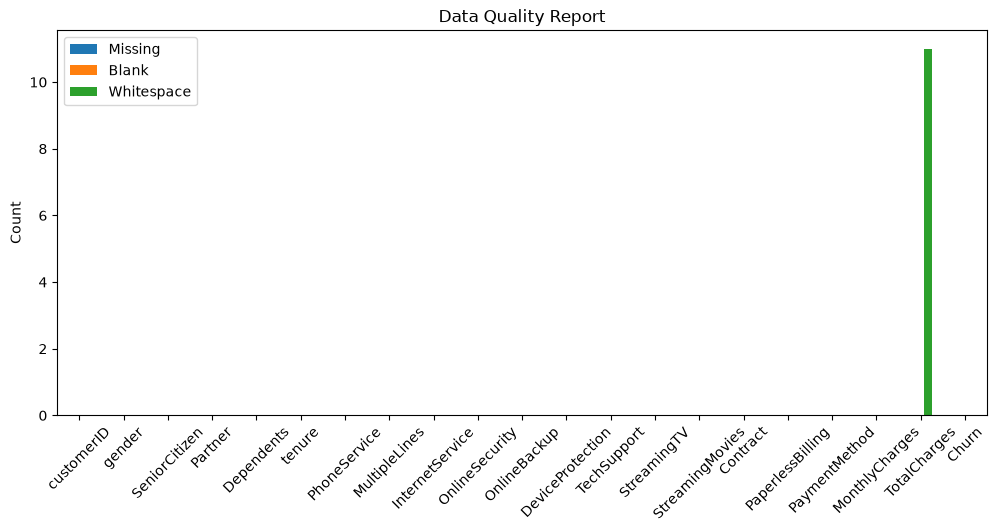

In [12]:
quality_report.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Data Quality Report")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()